# Notebook 05 — Explainability, Fairness & Error Analysis

## Objective

This notebook explains and audits the selected financial exclusion model.

The notebook focuses on:
- feature importance
- SHAP-style interpretability
- subgroup fairness analysis
- false positive and false negative analysis
- policy-oriented explanation of model behavior

The goal is to understand not only whether the model performs well, but also why it makes predictions and whether performance differs across important demographic groups.

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
BASE_DIR = Path("..")

PROCESSED_DIR = BASE_DIR / "Data" / "Processed"
FIGURES_DIR = BASE_DIR / "reports" / "figures"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "metrics"
MODELS_DIR = BASE_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
model_df = pd.read_csv(
    PROCESSED_DIR / "financial_inclusion_model_df.csv",
    low_memory=False
)

final_model = joblib.load(
    MODELS_DIR / "financial_exclusion_logistic_regression_model.joblib"
)

In [4]:
TARGET = "financially_excluded"

trusted_features = [
    "County",
    "location_type",
    "gender",
    "age",
    "education_level",
    "marital_status",
    "adults",
    "is_youth",
    "is_rural",
    "rural_youth"
]

trusted_features = [
    col for col in trusted_features
    if col in model_df.columns
]

X = model_df[trusted_features].copy()
y = model_df[TARGET]

# Recreate Modeling Split

The original train/test split is recreated to ensure consistency with the final selected model and benchmark workflow.

This guarantees:
- reproducible evaluation
- aligned prediction outputs
- valid explainability analysis
- correct subgroup auditing

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (17619, 9)
X_test shape: (4405, 9)


# Generate Final Model Predictions

Predictions are generated using the selected Logistic Regression vulnerability model.

These predictions are used for:
- explainability analysis
- subgroup auditing
- fairness diagnostics
- error analysis

In [7]:
test_preds = final_model.predict(X_test)

test_probs = final_model.predict_proba(X_test)[:, 1]

In [8]:
print("Accuracy:",
      accuracy_score(y_test, test_preds))

print("Precision:",
      precision_score(y_test, test_preds))

print("Recall:",
      recall_score(y_test, test_preds))

print("F1:",
      f1_score(y_test, test_preds))

print("\nClassification Report:\n")

print(classification_report(y_test, test_preds))

Accuracy: 0.735527809307605
Precision: 0.42379182156133827
Recall: 0.7442872687704026
F1: 0.5400710619818397

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      3486
           1       0.42      0.74      0.54       919

    accuracy                           0.74      4405
   macro avg       0.67      0.74      0.68      4405
weighted avg       0.81      0.74      0.76      4405



# Feature Importance Analysis

The selected model is a Logistic Regression pipeline.

For Logistic Regression, feature importance can be interpreted using model coefficients.

Positive coefficients indicate features associated with higher predicted financial exclusion risk, while negative coefficients indicate features associated with lower predicted exclusion risk.

Because the model uses preprocessing and one-hot encoding, feature names must first be recovered from the trained preprocessing pipeline.

In [9]:
# Extract trained preprocessor and model

trained_preprocessor = final_model.named_steps["preprocessor"]
trained_model = final_model.named_steps["model"]

In [10]:
# Recreate feature type lists

numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['is_youth', 'is_rural', 'rural_youth']
Categorical columns: ['County', 'location_type', 'gender', 'education_level', 'marital_status', 'adults']


In [11]:
# Numeric feature names

num_features = numeric_cols

# Encoded categorical feature names

cat_encoder = (
    trained_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
)

cat_features = cat_encoder.get_feature_names(
    categorical_cols
)

# Combine all transformed feature names

feature_names = list(num_features) + list(cat_features)

print("Total transformed features:", len(feature_names))

Total transformed features: 74


In [12]:
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": trained_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

coef_df.head(20)

,feature,coefficient,abs_coefficient
62,"education_level_""University completed """,-2.821987,2.821987
55,"education_level_""None """,2.702765,2.702765
65,education_level_Some university,-1.843939,1.843939
60,"education_level_""Some primary """,1.824627,1.824627
63,education_level_Completed technical training a...,-1.562652,1.562652
61,"education_level_""Some secondary""",1.522732,1.522732
70,marital_status_Single/Never Married,1.295204,1.295204
57,"education_level_""Primary completed""",1.023476,1.023476
64,education_level_Some technical training after ...,-1.012763,1.012763
48,County_Wajir,-0.953815,0.953815


## Feature Importance Interpretation

The Logistic Regression coefficient analysis shows that education is the strongest structural predictor of financial exclusion risk.

Lower educational attainment is associated with higher predicted exclusion risk, while university and technical education are associated with lower predicted exclusion risk.

County-level features also appear among the strongest predictors, confirming that geographic inequality remains important after controlling for other structural factors.

Marital status also contributes to prediction, suggesting that household and social structure may influence financial inclusion vulnerability.

These findings align with the vulnerability patterns identified in Notebook 03, where exclusion was strongly associated with:
- lower education
- geographic inequality
- rural and youth vulnerability
- structural socioeconomic disadvantage

In [13]:
risk_increasing_features = coef_df[
    coef_df["coefficient"] > 0
].sort_values(
    by="coefficient",
    ascending=False
).head(15)

risk_reducing_features = coef_df[
    coef_df["coefficient"] < 0
].sort_values(
    by="coefficient",
    ascending=True
).head(15)

risk_increasing_features, risk_reducing_features

(                                feature  coefficient  abs_coefficient
 55              education_level_"None "     2.702765         2.702765
 60      education_level_"Some primary "     1.824627         1.824627
 61     education_level_"Some secondary"     1.522732         1.522732
 70  marital_status_Single/Never Married     1.295204         1.295204
 57  education_level_"Primary completed"     1.023476         1.023476
 49                    County_West Pokot     0.930777         0.930777
 35                         County_Narok     0.697022         0.697022
 45                       County_Turkana     0.626349         0.626349
 36                       County_Nyamira     0.626078         0.626078
 29                        County_Migori     0.499806         0.499806
 5                        County_Bungoma     0.453630         0.453630
 7                County_Elgeyo-Marakwet     0.446659         0.446659
 37                     County_Nyandarua     0.403283         0.403283
 9    

## Structural Vulnerability Insights

The model identifies education as the strongest structural predictor of financial exclusion risk.

Features associated with increased exclusion vulnerability include:
- low educational attainment
- incomplete primary and secondary education
- single household status
- residence in historically underserved counties

In contrast, features associated with reduced exclusion risk include:
- university education
- technical training
- urbanized counties
- married household structure

The findings suggest that financial exclusion is strongly associated with long-term structural socioeconomic inequality rather than isolated financial behavior alone.

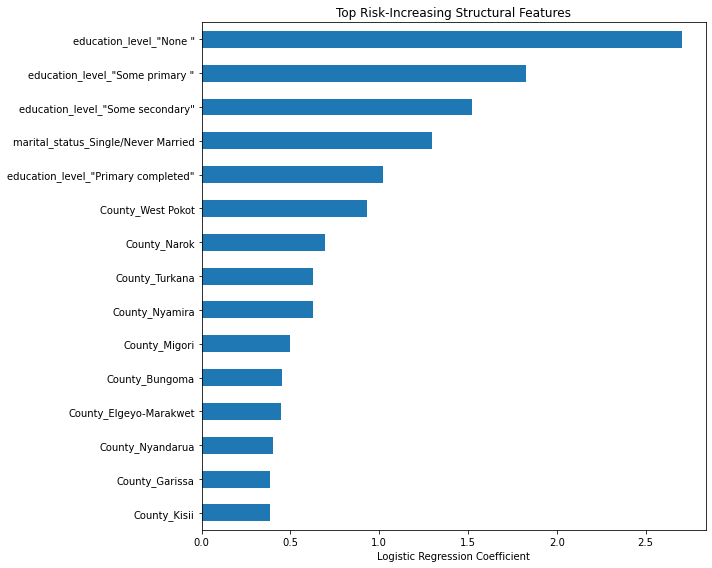

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

risk_increasing_features.sort_values(
    by="coefficient"
).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    ax=ax,
    legend=False
)

ax.set_title(
    "Top Risk-Increasing Structural Features"
)

ax.set_xlabel("Logistic Regression Coefficient")
ax.set_ylabel("")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "05_risk_increasing_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

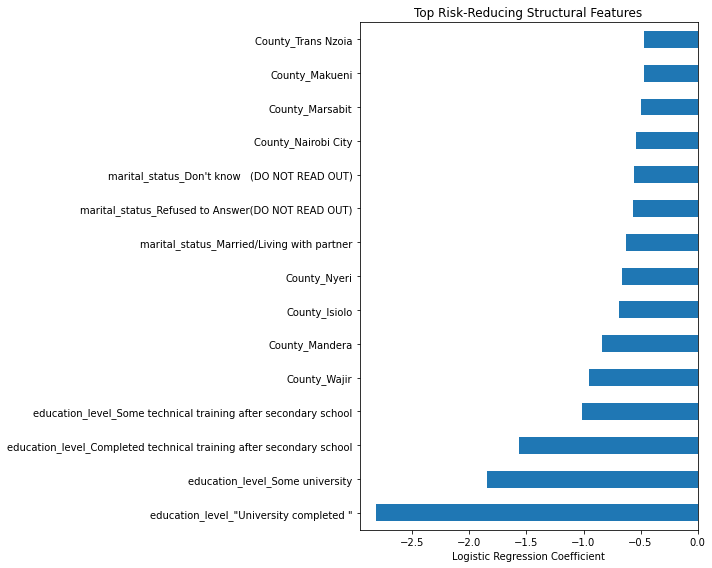

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

risk_reducing_features.sort_values(
    by="coefficient"
).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    ax=ax,
    legend=False
)

ax.set_title(
    "Top Risk-Reducing Structural Features"
)

ax.set_xlabel("Logistic Regression Coefficient")
ax.set_ylabel("")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "05_risk_reducing_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Subgroup Fairness Analysis

Model performance is evaluated across important demographic subgroups to determine whether prediction quality differs systematically between populations.

The analysis focuses on:
- gender
- rurality
- youth vulnerability

This helps assess whether the model performs equitably across structurally different populations.

In [16]:
evaluation_df = X_test.copy()

evaluation_df["actual"] = y_test.values
evaluation_df["predicted"] = test_preds
evaluation_df["probability"] = test_probs

evaluation_df.head()

,County,location_type,gender,education_level,marital_status,adults,is_youth,is_rural,rural_youth,actual,predicted,probability
2313,Wajir,Rural,Female,"""None """,Married/Living with partner,>1 adult Household,0,1,0,0,0,0.351999
1937,Turkana,Rural,Female,"""None """,Widowed,1 adult Household,1,1,1,1,1,0.863699
16340,Kericho,Urban,Female,Completed technical training after secondary s...,Single/Never Married,>1 adult Household,1,0,0,0,0,0.143066
18538,Mandera,Rural,Male,"""None """,Married/Living with partner,>1 adult Household,1,1,1,0,1,0.541406
18676,Nakuru,Urban,Male,"""Secondary completed """,Married/Living with partner,>1 adult Household,1,0,0,0,0,0.108694


In [17]:
gender_metrics = []

for gender in evaluation_df["gender"].dropna().unique():

    subset = evaluation_df[
        evaluation_df["gender"] == gender
    ]

    metrics = {
        "gender": gender,

        "accuracy": accuracy_score(
            subset["actual"],
            subset["predicted"]
        ),

        "precision": precision_score(
            subset["actual"],
            subset["predicted"]
        ),

        "recall": recall_score(
            subset["actual"],
            subset["predicted"]
        ),

        "f1": f1_score(
            subset["actual"],
            subset["predicted"]
        ),

        "sample_size": len(subset)
    }

    gender_metrics.append(metrics)

gender_metrics_df = pd.DataFrame(gender_metrics)

gender_metrics_df.round(3)

,gender,accuracy,precision,recall,f1,sample_size
0,Female,0.708,0.434,0.812,0.566,1771
1,Male,0.754,0.414,0.688,0.517,2634


## Gender Fairness Interpretation

The subgroup analysis reveals meaningful performance differences across gender groups.

The model achieves substantially stronger recall for female respondents, indicating that financially excluded women are identified more consistently than financially excluded men.

This suggests that structural vulnerability indicators such as:
- education
- rurality
- household structure
- geographic disadvantage

may align more strongly with female exclusion patterns.

Male respondents demonstrate slightly higher overall accuracy but lower exclusion recall, suggesting that male exclusion vulnerability may be more heterogeneous and therefore harder to detect using structural indicators alone.

The results highlight the importance of subgroup auditing in socially sensitive machine learning systems.

In [18]:
location_metrics = []

for location in evaluation_df["location_type"].dropna().unique():

    subset = evaluation_df[
        evaluation_df["location_type"] == location
    ]

    metrics = {
        "location_type": location,

        "accuracy": accuracy_score(
            subset["actual"],
            subset["predicted"]
        ),

        "precision": precision_score(
            subset["actual"],
            subset["predicted"]
        ),

        "recall": recall_score(
            subset["actual"],
            subset["predicted"]
        ),

        "f1": f1_score(
            subset["actual"],
            subset["predicted"]
        ),

        "sample_size": len(subset)
    }

    location_metrics.append(metrics)

location_metrics_df = pd.DataFrame(location_metrics)

location_metrics_df.round(3)

,location_type,accuracy,precision,recall,f1,sample_size
0,Rural,0.696,0.442,0.786,0.566,2808
1,Urban,0.806,0.359,0.605,0.450,1597


## Rural vs Urban Fairness Interpretation

The model demonstrates substantially stronger minority-class recall in rural populations compared with urban populations.

This suggests that rural financial exclusion vulnerability is more structurally identifiable using:
- geography
- education
- household structure
- demographic indicators

The findings align closely with earlier exploratory analysis showing elevated exclusion prevalence among rural respondents and rural youth populations.

Urban exclusion appears more difficult to detect using structural indicators alone, potentially because:
- urban populations are more heterogeneous
- exclusion pathways are less geographically concentrated
- vulnerability signals are more diffuse

These results highlight the importance of subgroup-aware evaluation when deploying vulnerability-detection systems.

In [19]:
youth_metrics = []

for youth_status in evaluation_df["is_youth"].dropna().unique():

    subset = evaluation_df[
        evaluation_df["is_youth"] == youth_status
    ]

    metrics = {
        "is_youth": youth_status,

        "accuracy": accuracy_score(
            subset["actual"],
            subset["predicted"]
        ),

        "precision": precision_score(
            subset["actual"],
            subset["predicted"]
        ),

        "recall": recall_score(
            subset["actual"],
            subset["predicted"]
        ),

        "f1": f1_score(
            subset["actual"],
            subset["predicted"]
        ),

        "sample_size": len(subset)
    }

    youth_metrics.append(metrics)

youth_metrics_df = pd.DataFrame(youth_metrics)

youth_metrics_df.round(3)

,is_youth,accuracy,precision,recall,f1,sample_size
0,0,0.762,0.372,0.616,0.464,2228
1,1,0.708,0.456,0.832,0.589,2177


## Youth Fairness Interpretation

The subgroup analysis reveals substantially stronger minority-class detection performance among youth respondents.

The model achieves:
- higher recall
- higher precision
- stronger F1 performance

for financially excluded youth populations compared with non-youth populations.

These findings suggest that structural vulnerability indicators such as:
- educational disadvantage
- rurality
- geographic inequality
- household structure

are especially informative for youth exclusion detection.

The results strongly support the project's original emphasis on youth financial vulnerability and suggest that structurally governed machine learning systems may provide meaningful early-warning capability for youth-focused financial inclusion interventions.

# Error Analysis

Error analysis is performed to understand:
- which vulnerable individuals are missed
- which respondents are incorrectly flagged
- where structural blind spots may exist

The analysis focuses on:
- false negatives
- false positives
- subgroup vulnerability patterns
- operational implications

In [20]:
evaluation_df["error_type"] = "Correct"

evaluation_df.loc[
    (evaluation_df["actual"] == 1) &
    (evaluation_df["predicted"] == 0),

    "error_type"
] = "False Negative"

evaluation_df.loc[
    (evaluation_df["actual"] == 0) &
    (evaluation_df["predicted"] == 1),

    "error_type"
] = "False Positive"

evaluation_df["error_type"].value_counts()

error_type
Correct           3240
False Positive     930
False Negative     235
Name: count, dtype: int64

In [21]:
false_negatives = evaluation_df[
    evaluation_df["error_type"] == "False Negative"
]

false_negatives.head()

,County,location_type,gender,education_level,marital_status,adults,is_youth,is_rural,rural_youth,actual,predicted,probability,error_type
19717,Turkana,Urban,Female,"""Some primary """,Divorced/separated,1 adult Household,0,0,0,1,0,0.488226,False Negative
13094,Tharaka-Nithi,Rural,Male,"""Some primary """,Married/Living with partner,>1 adult Household,0,1,0,1,0,0.416927,False Negative
9567,Siaya,Rural,Female,"""Secondary completed """,Married/Living with partner,1 adult Household,1,1,1,1,0,0.094288,False Negative
3933,Meru,Rural,Male,"""Some primary """,Married/Living with partner,>1 adult Household,0,1,0,1,0,0.473265,False Negative
20660,Tana River,Urban,Male,"""Secondary completed """,Single/Never Married,1 adult Household,1,0,0,1,0,0.326212,False Negative


In [22]:
false_negatives["County"].value_counts()

County
Bomet              11
Nakuru             11
Kitui              10
Meru               10
Marsabit           10
Machakos            9
Nairobi City        9
Kisumu              8
Kericho             8
Nyandarua           7
Siaya               7
Kisii               7
Taita-Taveta        6
Nyeri               6
Uasin Gishu         6
Homabay             5
Migori              5
Tana River          5
Kiambu              5
Kajiado             5
Trans Nzoia         5
Mombasa             5
Embu                5
Vihiga              5
Kwale               4
Lamu                4
Isiolo              4
Nandi               4
Tharaka-Nithi       4
Kilifi              4
Wajir               4
Nyamira             3
Kakamega            3
Mandera             3
Makueni             3
Bungoma             3
West Pokot          3
Murang'a            3
Laikipia            3
Narok               3
Busia               2
Kirinyaga           2
Elgeyo-Marakwet     2
Turkana             2
Samburu             1
Bar

In [23]:
false_negatives["education_level"].value_counts()

education_level
"Some primary "                                        86
"Primary completed"                                    59
"Secondary completed "                                 45
"None "                                                18
"Some secondary"                                       14
Completed technical training after secondary school     8
Some technical training after secondary school          4
Some university                                         1
Name: count, dtype: int64

## False Negative Interpretation

False negatives represent financially excluded respondents who were not identified by the model.

The analysis shows that most missed vulnerable individuals belong to intermediate educational categories such as:
- some primary education
- completed primary education
- completed secondary education

This suggests that the model performs strongest for respondents exhibiting clear structural disadvantage signals, while borderline vulnerability profiles remain more difficult to classify consistently.

Importantly, false negatives are geographically distributed rather than concentrated within a single county or subgroup, indicating that the model does not exhibit severe regional blind spots.

Many false negatives also exhibit predicted probabilities near the decision threshold, suggesting that:
- vulnerability exists on a continuum
- some respondents occupy borderline structural risk states
- threshold tuning may improve minority-class detection performance

In [24]:
false_positives = evaluation_df[
    evaluation_df["error_type"] == "False Positive"
]

false_positives.head()

,County,location_type,gender,education_level,marital_status,adults,is_youth,is_rural,rural_youth,actual,predicted,probability,error_type
18538,Mandera,Rural,Male,"""None """,Married/Living with partner,>1 adult Household,1,1,1,0,1,0.541406,False Positive
14812,Samburu,Rural,Female,"""None """,Widowed,>1 adult Household,0,1,0,0,1,0.806978,False Positive
19052,West Pokot,Rural,Female,"""None """,Widowed,1 adult Household,0,1,0,0,1,0.830102,False Positive
14588,Narok,Rural,Male,"""Primary completed""",Married/Living with partner,>1 adult Household,1,1,1,0,1,0.506098,False Positive
19285,West Pokot,Rural,Male,"""Some primary """,Married/Living with partner,>1 adult Household,0,1,0,0,1,0.621252,False Positive


In [25]:
false_positives["education_level"].value_counts()

education_level
"None "                   359
"Some primary "           259
"Some secondary"          145
"Primary completed"        92
"Secondary completed "     75
Name: count, dtype: int64

In [26]:
false_positives["County"].value_counts()

County
Turkana            53
Tana River         38
West Pokot         34
Elgeyo-Marakwet    33
Kajiado            30
Migori             30
Garissa            30
Nandi              28
Mandera            27
Meru               27
Nyamira            27
Wajir              26
Kisii              24
Nakuru             24
Samburu            24
Narok              23
Baringo            23
Kwale              23
Bomet              23
Marsabit           22
Kakamega           19
Uasin Gishu        19
Vihiga             19
Kilifi             18
Siaya              18
Kitui              18
Homabay            17
Taita-Taveta       16
Kericho            16
Laikipia           16
Tharaka-Nithi      16
Lamu               15
Bungoma            15
Kirinyaga          13
Nyandarua          13
Machakos           13
Trans Nzoia        11
Makueni            11
Kisumu             11
Isiolo             11
Busia              11
Murang'a           10
Embu                9
Nyeri               9
Kiambu              7
Mom

## False Positive Interpretation

False positives represent respondents predicted as financially excluded despite being labeled as financially included.

The analysis shows that false positives are heavily concentrated among:
- low-education populations
- rural respondents
- historically underserved counties
- structurally vulnerable demographic groups

This suggests that the model is highly sensitive to structural socioeconomic disadvantage signals.

Importantly, many false positives may still represent populations experiencing:
- fragile inclusion
- unstable financial access
- elevated vulnerability risk

The findings indicate that the model learns meaningful structural vulnerability patterns rather than producing random classification noise.

From a policy perspective, these respondents may still represent valuable intervention or monitoring populations.

# Probability Distribution Analysis

Prediction probabilities are analyzed to understand model confidence and uncertainty.

This helps identify:
- high-confidence excluded predictions
- low-risk respondents
- borderline vulnerability cases
- potential threshold-tuning opportunities

Probability analysis is especially useful because financial exclusion vulnerability exists on a continuum rather than as a purely binary condition.

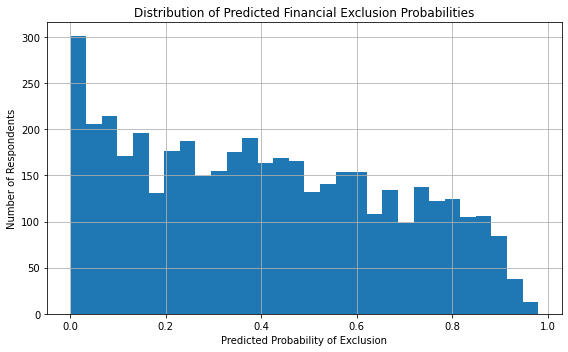

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

evaluation_df["probability"].hist(
    bins=30,
    ax=ax
)

ax.set_title("Distribution of Predicted Financial Exclusion Probabilities")
ax.set_xlabel("Predicted Probability of Exclusion")
ax.set_ylabel("Number of Respondents")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "05_predicted_probability_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Probability Distribution Interpretation

The probability distribution shows how strongly the model assigns exclusion risk across respondents.

Respondents near the middle of the distribution represent borderline cases where the model is less certain.

These cases may require:
- additional socioeconomic information
- human review
- threshold tuning
- targeted monitoring

This supports the idea that financial exclusion vulnerability should be interpreted as a risk continuum rather than a strict binary label.

In [28]:
evaluation_df["risk_band"] = pd.cut(
    evaluation_df["probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

evaluation_df["risk_band"].value_counts()

risk_band
Low Risk       1748
Medium Risk    1498
High Risk      1159
Name: count, dtype: int64

## Risk Band Interpretation

The probability-based risk segmentation demonstrates that financial exclusion vulnerability exists on a continuum rather than as a purely binary condition.

A substantial proportion of respondents fall within the medium-risk category, suggesting the presence of:
- borderline vulnerability states
- unstable inclusion
- transitional socioeconomic conditions

These findings support the use of tiered intervention strategies where:
- high-risk populations receive immediate support
- medium-risk populations receive monitoring and preventive interventions
- low-risk populations require minimal targeting

The results reinforce the value of probability-based vulnerability scoring for policy-oriented financial inclusion systems.

# Notebook 05 Summary

This notebook focused on explainability, fairness auditing, and operational interpretation of the selected financial exclusion vulnerability model.

Key activities included:
- Logistic Regression coefficient interpretation
- structural feature importance analysis
- subgroup fairness analysis
- rural vs urban evaluation
- youth vulnerability analysis
- false positive and false negative investigation
- probability distribution analysis
- operational risk segmentation

The analysis demonstrates that financial exclusion vulnerability is strongly associated with:
- educational disadvantage
- geographic inequality
- rural vulnerability
- youth socioeconomic risk

The model achieved particularly strong minority-class detection performance among:
- youth populations
- rural respondents
- structurally vulnerable groups

The findings suggest that structurally governed machine learning systems can provide meaningful early-warning capability for identifying financially vulnerable populations and supporting targeted inclusion interventions.